## Pruebas Algoritmos

In [ ]:
import pandas as pd
import numpy as np
import time
import os
import json
from tqdm import tqdm 
from typing import Tuple, List

# ✅ PASO 1: Importa el archivo con tus funciones de detección
import algoritmos_deteccion as ad

# =============================================================================
# SECCIÓN DE EVALUACIÓN
# =============================================================================

def calcular_iou(real: Tuple[int, int], detectado: Tuple[int, int]) -> float:
    """Calcula el Índice Jaccard (Intersection over Union) entre dos intervalos."""
    inicio_real, fin_real = real
    inicio_det, fin_det = detectado
    interseccion = max(0, min(fin_real, fin_det) - max(inicio_real, inicio_det))
    union = (fin_real - inicio_real) + (fin_det - inicio_det) - interseccion
    return interseccion / union if union > 0 else 0.0


def evaluar_detecciones(eventos_reales: List[Tuple[int, int]], detectados: List[Tuple[int, int]]) -> Tuple[float, int, int, int]:
    """
    Evalúa las detecciones contra los eventos reales. Maneja múltiples eventos por señal.
    Devuelve: IoU promedio, TP, FN, FP.
    """
    # Si no hay eventos reales, todas las detecciones son Falsos Positivos.
    if not eventos_reales:
        return 0.0, 0, 0, len(detectados)

    # Si no hay detecciones, todos los eventos reales son Falsos Negativos.
    if not detectados:
        return 0.0, 0, len(eventos_reales), 0

    detectados_copia = detectados[:]
    mejores_ious = []
    tp = 0
    umbral_iou_tp = 0.5 # Usando el umbral estricto que prefieres

    # Itera sobre cada evento REAL para encontrarle su mejor pareja
    for real in eventos_reales:
        if not detectados_copia: # Si ya no quedan detecciones para emparejar
            break
            
        # Calcula el IoU del evento real actual contra TODAS las detecciones restantes
        ious = [calcular_iou(real, det) for det in detectados_copia]
        mejor_iou_idx = np.argmax(ious)
        mejor_iou = ious[mejor_iou_idx]
        
        # Si la mejor pareja supera el umbral, es un Verdadero Positivo
        if mejor_iou >= umbral_iou_tp:
            tp += 1
            mejores_ious.append(mejor_iou)
            # IMPORTANTE: Elimina la detección usada para que no pueda ser re-emparejada
            detectados_copia.pop(mejor_iou_idx)
        else:
            # Si no hay una buena pareja para este evento real, su IoU es 0
            mejores_ious.append(0.0)

    # Al final del bucle:
    fn = len(eventos_reales) - tp  # Falsos Negativos = Los reales que no encontraron pareja
    fp = len(detectados_copia)     # Falsos Positivos = Las detecciones que sobraron
    
    iou_promedio = np.mean(mejores_ious) if tp > 0 else 0.0
    
    return iou_promedio, tp, fn, fp

# --- CONFIGURACIÓN PRINCIPAL ---

BASE_DIR = r'..\Generacion_Señales'
DIRS = {
    'Sag': os.path.join(BASE_DIR, 'Sag'),
    'Sag_Armonic': os.path.join(BASE_DIR, 'Sag_Armonic'),
    'Sag_Multiple': os.path.join(BASE_DIR, 'Sag_Multiple'),
    'Sag_Notch': os.path.join(BASE_DIR, 'Sag_Notch'),
    'Sag_Transitorios': os.path.join(BASE_DIR, 'Sag_Transitorios')
}

print("Cargando y consolidando metadatos...")
todos_los_metadata = []
for dir_nombre, dir_path in DIRS.items():
    for filename in os.listdir(dir_path):
        if 'metadata' in filename:
            try:
                df_meta = pd.read_csv(os.path.join(dir_path, filename))
                df_meta['SourceDir'] = dir_nombre
                todos_los_metadata.append(df_meta)
                print(f"  - Cargado: {filename} ({len(df_meta)} filas)")
            except Exception as e:
                print(f"Error cargando {filename}: {e}")

metadata_df = pd.concat(todos_los_metadata, ignore_index=True)
print(f"\nTotal de señales a evaluar: {len(metadata_df)}")

mapa_archivos = {
    'sags.csv': ['sag'],
    'sags_con_ruido.csv': ['sag_ruido'],
    'sags_con_armonicos.csv': ['armonicos_solo'],
    'sags_con_armonicos_y_ruido.csv': ['armonicos_y_ruido'],
    'sags_multiples.csv': ['multiple_limpio'],
    'sags_multiples_con_ruido.csv': ['multiple_con_ruido'],
    'sags_con_muescas.csv': ['muescas_limpio'],
    'sags_con_muescas_y_ruido.csv': ['muescas_con_ruido'],
    'sags_con_transitorios.csv': ['transitorio_limpio'],
    'sags_con_transitorios_y_ruido.csv': ['transitorio_con_ruido']
}

tipo_a_archivo = {tipo: (DIRS[dirname], fname) for dirname, fnames in {
    'Sag': ['sags.csv', 'sags_con_ruido.csv'],
    'Sag_Armonic': ['sags_con_armonicos.csv', 'sags_con_armonicos_y_ruido.csv'],
    'Sag_Multiple': ['sags_multiples.csv', 'sags_multiples_con_ruido.csv'],
    'Sag_Notch': ['sags_con_muescas.csv', 'sags_con_muescas_y_ruido.csv'],
    'Sag_Transitorios': ['sags_con_transitorios.csv', 'sags_con_transitorios_y_ruido.csv']
}.items() for fname in fnames for tipo in mapa_archivos.get(fname, [])}

# --- EJECUCIÓN DE LA EVALUACIÓN (VERSIÓN OPTIMIZADA) ---

fs = 7200
algoritmos = [
    ("RMS", lambda senal: ad.detectar_eventos_rms(senal, fs=fs)),
    ("Hilbert", lambda senal: ad.detectar_eventos_hilbert(senal, fs=fs)),
    ("SWT", lambda senal: ad.detectar_eventos_swt(senal, fs=fs)),
    ("Fusion", lambda senal: ad.detectar_eventos_con_fusion(senal, fs=fs))
]

# ✅ **OPTIMIZACIÓN: Crear un caché para los DataFrames cargados**
signal_data_cache = {}
resultados = []

print("\nIniciando evaluación con caché de datos optimizado...")
for _, fila in tqdm(metadata_df.iterrows(), total=len(metadata_df), desc="Evaluando señales"):
    
    id_sag = fila['ID_Sag']
    
    # ✅ --- INICIA LA CORRECCIÓN ---
    # Lógica mejorada para manejar metadatos antiguos sin la columna 'tipo'
    tipo_evento = fila['tipo']
    if pd.isna(tipo_evento):
        # Si el tipo es NaN, es de los metadatos antiguos. Lo deducimos del ID.
        if 'ruido' in id_sag.lower():
            tipo_evento = 'sag_ruido'
        else:
            tipo_evento = 'sag'
    # ✅ --- TERMINA LA CORRECCIÓN ---

    try:
        # Construye la ruta completa al archivo CSV necesario
        dir_path, archivo_csv_nombre = tipo_a_archivo[tipo_evento]
        ruta_completa_csv = os.path.join(dir_path, archivo_csv_nombre)

        # 1. Revisa si el archivo ya está en el caché
        if ruta_completa_csv not in signal_data_cache:
            # Si no está, cárgalo UNA VEZ y guárdalo en el caché
            signal_data_cache[ruta_completa_csv] = pd.read_csv(ruta_completa_csv, index_col='Tiempo')
        
        # 2. Obtén la señal desde el caché en memoria (mucho más rápido)
        df_senal_cacheado = signal_data_cache[ruta_completa_csv]
        senal = df_senal_cacheado[id_sag].to_numpy()

    except KeyError:
        # print(f"ADVERTENCIA: No se encontró el archivo para el tipo '{tipo_evento}' o la señal '{id_sag}'. Saltando.")
        continue
    except Exception as e:
        print(f"Error procesando la señal {id_sag}: {e}")
        continue

    #carga los eventos reales si existen
    if 'eventos_reales' in fila and pd.notna(fila['eventos_reales']):
        ground_truth = json.loads(fila['eventos_reales'])
    else:
        ground_truth = [(fila['inicio_muestra'], fila['fin_muestra'])]

    for nombre_alg, func_alg in algoritmos:
        start_time = time.perf_counter()
        intervalos_detectados = func_alg(senal)
        end_time = time.perf_counter()

        mejor_iou, tp, fn, fp = evaluar_detecciones(ground_truth, intervalos_detectados)
        
        resultados.append({
            'ID_Sag': id_sag, 'Tipo_Evento': tipo_evento, 'Algoritmo': nombre_alg,
            'Tiempo_ms': (end_time - start_time) * 1000, 'IoU': mejor_iou,
            'TP': tp, 'FN': fn, 'FP': fp
        })

# --- ANÁLISIS Y GUARDADO DE RESULTADOS ---

resultados_df = pd.DataFrame(resultados)
ruta_resultados = os.path.join(BASE_DIR, 'resultados_evaluacion.csv')
resultados_df.to_csv(ruta_resultados, index=False)
print(f"\n✅ ¡Evaluación completada! Resultados guardados en '{ruta_resultados}'")

summary = resultados_df.groupby('Algoritmo').agg(
    Tiempo_Promedio_ms=('Tiempo_ms', 'mean'),
    IoU_Promedio=('IoU', 'mean'),
    Total_TP=('TP', 'sum'),
    Total_FN=('FN', 'sum'),
    Total_FP=('FP', 'sum')
).reset_index()

summary['Precision'] = summary['Total_TP'] / (summary['Total_TP'] + summary['Total_FP'])
summary['Sensibilidad'] = summary['Total_TP'] / (summary['Total_TP'] + summary['Total_FN'])
summary['F1_Score'] = 2 * (summary['Precision'] * summary['Sensibilidad']) / (summary['Precision'] + summary['Sensibilidad'])
summary = summary.fillna(0)

print("\n--- 📊 RESUMEN DE RENDIMIENTO POR ALGORITMO ---")
print(summary.to_string(index=False, float_format="%.4f"))

## Costo Computacional

--- Probando con N = 5000 muestras ---
  RMS: 0.0014 segundos
  Hilbert: 0.0008 segundos
  SWT (Wavelet): 0.0006 segundos
  Fusión Híbrida: 0.0019 segundos
--- Probando con N = 10000 muestras ---
  RMS: 0.0016 segundos
  Hilbert: 0.0012 segundos
  SWT (Wavelet): 0.0011 segundos
  Fusión Híbrida: 0.0034 segundos
--- Probando con N = 20000 muestras ---
  RMS: 0.0028 segundos
  Hilbert: 0.0019 segundos
  SWT (Wavelet): 0.0020 segundos
  Fusión Híbrida: 0.0060 segundos
--- Probando con N = 50000 muestras ---
  RMS: 0.0068 segundos
  Hilbert: 0.0042 segundos
  SWT (Wavelet): 0.0051 segundos
  Fusión Híbrida: 0.0162 segundos
--- Probando con N = 100000 muestras ---
  RMS: 0.0126 segundos
  Hilbert: 0.0090 segundos
  SWT (Wavelet): 0.0098 segundos
  Fusión Híbrida: 0.0343 segundos
--- Probando con N = 200000 muestras ---
  RMS: 0.0249 segundos
  Hilbert: 0.0187 segundos
  SWT (Wavelet): 0.0207 segundos
  Fusión Híbrida: 0.0636 segundos
--- Probando con N = 500000 muestras ---
  RMS: 0.0622 se

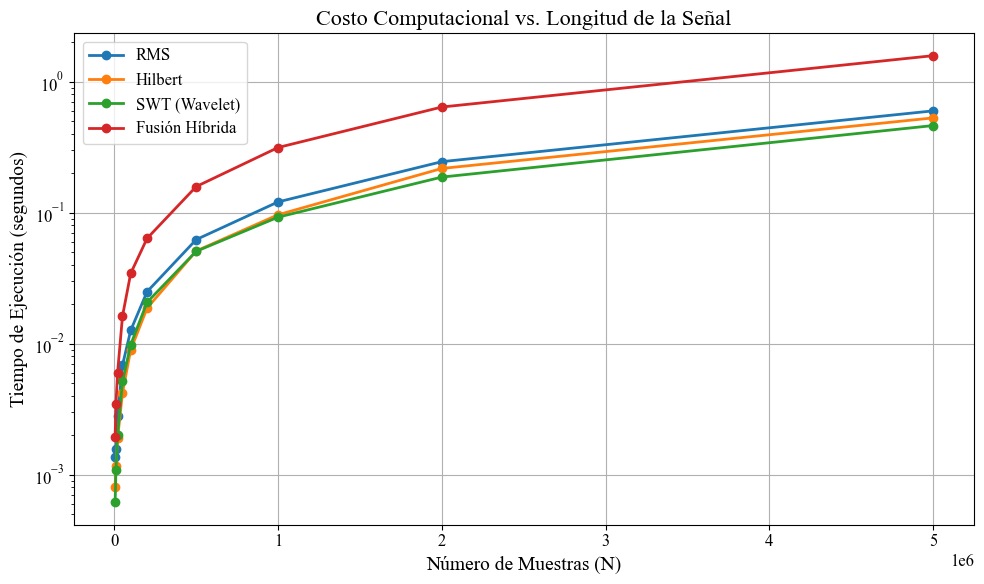

In [2]:
# Nombre del archivo: benchmark.py

import numpy as np
import time
import matplotlib.pyplot as plt

# Importa el archivo con tus funciones de detección
import algoritmos_deteccion as ad

# =============================================================================
# ✅ PASO 1: Define tu función de estilo académico aquí
# =============================================================================
def _setup_academic_style():
    """Configura los parámetros de Matplotlib para un estilo tipo IEEE."""
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
    plt.rcParams['mathtext.fontset'] = 'stix'
    plt.rcParams['font.size'] = 12
    plt.rcParams['axes.labelsize'] = 14 # Ajustado para mejor balance
    plt.rcParams['axes.titlesize'] = 16
    plt.rcParams['xtick.labelsize'] = 12
    plt.rcParams['ytick.labelsize'] = 12
    plt.rcParams['legend.fontsize'] = 12
    plt.rcParams['figure.figsize'] = (10, 6) # Ligeramente más alto para mejor lectura
    plt.rcParams['lines.linewidth'] = 2.0



# =============================================================================
# SECCIÓN DE PRUEBA DE RENDIMIENTO (BENCHMARK)
# =============================================================================

# 1. Definir los tamaños de señal (N muestras) para la prueba
n_muestras_lista = [5000, 10000, 20000, 50000, 100000, 200000, 500000, 1000000, 2000000, 5000000]
fs = 7200

# 2. Diccionario para almacenar los resultados
tiempos_ejecucion = {
    "RMS": [],
    "Hilbert": [],
    "SWT (Wavelet)": [],
    "Fusión Híbrida": []
}

# 3. Bucle principal para ejecutar la prueba
for n_muestras in n_muestras_lista:
    print(f"--- Probando con N = {n_muestras} muestras ---")
    
    # Crear una señal de prueba sintética con un hueco de tensión
    t = np.arange(n_muestras) / fs
    senal_prueba = np.sin(2 * np.pi * 60 * t) + 0.1 * np.random.randn(n_muestras)
    senal_prueba[n_muestras // 4 : n_muestras // 2] *= 0.5

    # --- Medición explícita para cada algoritmo ---
    # (El resto del bucle de medición queda exactamente igual)

    # Medición para RMS
    start_time = time.perf_counter()
    ad.detectar_eventos_rms(senal_prueba, fs=fs)
    end_time = time.perf_counter()
    tiempos_ejecucion["RMS"].append(end_time - start_time)
    print(f'  RMS: {end_time - start_time:.4f} segundos')

    # Medición para Hilbert
    start_time = time.perf_counter()
    ad.detectar_eventos_hilbert(senal_prueba, fs=fs)
    end_time = time.perf_counter()
    tiempos_ejecucion["Hilbert"].append(end_time - start_time)
    print(f'  Hilbert: {end_time - start_time:.4f} segundos')
    
    # Medición para SWT (Wavelet)
    start_time = time.perf_counter()
    ad.detectar_eventos_swt(senal_prueba, fs=fs)
    end_time = time.perf_counter()
    tiempos_ejecucion["SWT (Wavelet)"].append(end_time - start_time)
    print(f'  SWT (Wavelet): {end_time - start_time:.4f} segundos')

    # Medición para Fusión Híbrida
    start_time = time.perf_counter()
    ad.detectar_eventos_con_fusion(senal_prueba, fs=fs)
    end_time = time.perf_counter()
    tiempos_ejecucion["Fusión Híbrida"].append(end_time - start_time)
    print(f'  Fusión Híbrida: {end_time - start_time:.4f} segundos')


# =============================================================================
# ✅ PASO 2: Llama a tu función de estilo antes de graficar
# =============================================================================
_setup_academic_style() # Aplicamos el estilo personalizado

plt.figure() # Usamos la configuración de figsize definida en la función

for nombre, tiempos in tiempos_ejecucion.items():
    plt.plot(n_muestras_lista, tiempos, marker='o', linestyle='-', label=nombre)
title = "Costo Computacional"
plt.xlabel("Número de Muestras (N)")
plt.ylabel("Tiempo de Ejecución (segundos)")
plt.title("Costo Computacional vs. Longitud de la Señal")
plt.legend()
plt.grid(True) # Añadimos una rejilla que siempre es útil
plt.yscale('log')
# plt.xticks(n_muestras_lista, rotation=25) # La rotación puede no ser necesaria
plt.tight_layout()
file_name = f"{title.replace(' ', '_').lower()}.svg"
plt.savefig(file_name, format='svg', dpi=300)
plt.show()